In [49]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os

In [50]:
df_multi = pd.read_csv('datasets/Training.csv')
print("Shape:", df_multi.shape)
print("\nDiseases in dataset:")
print(df_multi['Disease'].value_counts())

Shape: (4920, 18)

Diseases in dataset:
Disease
Fungal infection                           120
Allergy                                    120
GERD                                       120
Chronic cholestasis                        120
Drug Reaction                              120
Peptic ulcer diseae                        120
AIDS                                       120
Diabetes                                   120
Gastroenteritis                            120
Bronchial Asthma                           120
Hypertension                               120
Migraine                                   120
Cervical spondylosis                       120
Paralysis (brain hemorrhage)               120
Jaundice                                   120
Malaria                                    120
Chicken pox                                120
Dengue                                     120
Typhoid                                    120
hepatitis A                                120
Hepatitis B 

In [51]:

target_diseases = [
    'Malaria', 'Typhoid', 'Pneumonia', 'Dengue',
    'Hepatitis B', 'Tuberculosis', 'Hypertension',
    'Urinary tract infection', 'Chicken pox',
    'Jaundice', 'Hepatitis A', 'Migraine',
    'Gastroenteritis', 'Bronchial Asthma', 'Common Cold'
]
df_filtered = df_multi[df_multi['Disease'].isin(target_diseases)].copy()

symptom_cols = ['Symptom_1','Symptom_2','Symptom_3','Symptom_4','Symptom_5',
                'Symptom_6','Symptom_7','Symptom_8','Symptom_9','Symptom_10',
                'Symptom_11','Symptom_12','Symptom_13','Symptom_14','Symptom_15',
                'Symptom_16','Symptom_17']

all_symptoms = set()
for col in symptom_cols:
    all_symptoms.update(df_filtered[col].dropna().str.strip().unique())

all_symptoms = sorted(list(all_symptoms))
print("Diseases kept:", df_filtered['Disease'].value_counts().to_dict())
print("Unique symptoms found:", len(all_symptoms))

Diseases kept: {'Gastroenteritis': 120, 'Bronchial Asthma': 120, 'Migraine': 120, 'Jaundice': 120, 'Malaria': 120, 'Chicken pox': 120, 'Dengue': 120, 'Typhoid': 120, 'Hepatitis B': 120, 'Tuberculosis': 120, 'Common Cold': 120, 'Pneumonia': 120, 'Urinary tract infection': 120}
Unique symptoms found: 61


In [52]:
def create_binary_df(df, symptom_list):
    rows = []
    for _, row in df.iterrows():
        symptoms_present = set()
        for col in symptom_cols:
            if pd.notna(row[col]):
                symptoms_present.add(row[col].strip())
        
        binary_row = {symptom: 1 if symptom in symptoms_present else 0 
                      for symptom in symptom_list}
        binary_row['disease'] = row['Disease']
        rows.append(binary_row)
    
    return pd.DataFrame(rows)

# First create df_symptoms
df_symptoms = create_binary_df(df_filtered, all_symptoms)
print("Shape:", df_symptoms.shape)
print("Disease counts:")
print(df_symptoms['disease'].value_counts())

# THEN add noise
import numpy as np
np.random.seed(42)

X_temp = df_symptoms.drop(columns=['disease'])
y_temp = df_symptoms['disease']

# Convert to numpy array for noise addition
X_array = X_temp.values.astype(float)

# Flip 15% of symptom values
noise_mask = np.random.random(X_array.shape) < 0.15
X_array[noise_mask] = 1 - X_array[noise_mask]

# Convert back to dataframe
X_noisy = pd.DataFrame(X_array, columns=X_temp.columns)
df_symptoms = X_noisy.copy()
df_symptoms['disease'] = y_temp.values

print("Real-world noise simulation applied")
print("15% symptom variation introduced")
print("New shape:", df_symptoms.shape)

Shape: (1560, 62)
Disease counts:
disease
Gastroenteritis            120
Bronchial Asthma           120
Migraine                   120
Jaundice                   120
Malaria                    120
Chicken pox                120
Dengue                     120
Typhoid                    120
Hepatitis B                120
Tuberculosis               120
Common Cold                120
Pneumonia                  120
Urinary tract infection    120
Name: count, dtype: int64
Real-world noise simulation applied
15% symptom variation introduced
New shape: (1560, 62)


In [53]:
df_diabetes = pd.read_csv('datasets/diabetes.csv')

cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_to_fix:
    df_diabetes[col] = df_diabetes[col].replace(0, df_diabetes[col].mean())

# Keep ALL rows this time, not just positive cases
df_diabetes['disease'] = df_diabetes['Outcome'].map({1: 'Diabetes', 0: 'No Diabetes'})
df_diabetes = df_diabetes.drop(columns=['Outcome'])

df_heart = pd.read_csv('datasets/heart.csv')
df_heart['disease'] = df_heart['condition'].map({1: 'Heart Disease', 0: 'No Heart Disease'})
df_heart = df_heart.drop(columns=['condition'])

print("Diabetes dataset:", df_diabetes.shape)
print(df_diabetes['disease'].value_counts())
print("\nHeart dataset:", df_heart.shape)
print(df_heart['disease'].value_counts())

Diabetes dataset: (768, 9)
disease
No Diabetes    500
Diabetes       268
Name: count, dtype: int64

Heart dataset: (297, 14)
disease
No Heart Disease    160
Heart Disease       137
Name: count, dtype: int64


In [54]:
# Train Model 1 — Symptom based (Common Diseases)
X_symptoms = df_symptoms.drop(columns=['disease'])
y_symptoms = df_symptoms['disease']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_symptoms, y_symptoms, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_symptoms
)

model_symptoms = RandomForestClassifier(n_estimators=100, random_state=42)
model_symptoms.fit(X_train_s, y_train_s)

y_pred_s = model_symptoms.predict(X_test_s)

print("=== Symptom Model (Common Diseases) ===")
print("Accuracy:", round(accuracy_score(y_test_s, y_pred_s) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test_s, y_pred_s))

=== Symptom Model (Common Diseases) ===
Accuracy: 96.15 %

Classification Report:
                         precision    recall  f1-score   support

       Bronchial Asthma       0.96      1.00      0.98        24
            Chicken pox       1.00      1.00      1.00        24
            Common Cold       1.00      1.00      1.00        24
                 Dengue       1.00      0.96      0.98        24
        Gastroenteritis       0.88      0.92      0.90        24
            Hepatitis B       1.00      1.00      1.00        24
               Jaundice       1.00      0.96      0.98        24
                Malaria       0.86      1.00      0.92        24
               Migraine       1.00      0.92      0.96        24
              Pneumonia       0.96      0.92      0.94        24
           Tuberculosis       1.00      0.96      0.98        24
                Typhoid       0.88      0.96      0.92        24
Urinary tract infection       1.00      0.92      0.96        24

      

In [55]:
# Train Model 2 — Diabetes
X_diabetes = df_diabetes.drop(columns=['disease'])
y_diabetes = df_diabetes['disease']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diabetes, y_diabetes,
    test_size=0.2,
    random_state=42,
    stratify=y_diabetes
)

model_diabetes = RandomForestClassifier(n_estimators=100, random_state=42)
model_diabetes.fit(X_train_d, y_train_d)

y_pred_d = model_diabetes.predict(X_test_d)

print("=== Diabetes Model ===")
print("Accuracy:", round(accuracy_score(y_test_d, y_pred_d) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test_d, y_pred_d))

=== Diabetes Model ===
Accuracy: 77.92 %

Classification Report:
              precision    recall  f1-score   support

    Diabetes       0.74      0.57      0.65        54
 No Diabetes       0.79      0.89      0.84       100

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.77      0.78      0.77       154



In [56]:
# Train Model 3 — Heart Disease
X_heart = df_heart.drop(columns=['disease'])
y_heart = df_heart['disease']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart,
    test_size=0.2,
    random_state=42,
    stratify=y_heart
)

model_heart = RandomForestClassifier(n_estimators=100, random_state=42)
model_heart.fit(X_train_h, y_train_h)

y_pred_h = model_heart.predict(X_test_h)

print("=== Heart Disease Model ===")
print("Accuracy:", round(accuracy_score(y_test_h, y_pred_h) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test_h, y_pred_h))

=== Heart Disease Model ===
Accuracy: 76.67 %

Classification Report:
                  precision    recall  f1-score   support

   Heart Disease       0.82      0.64      0.72        28
No Heart Disease       0.74      0.88      0.80        32

        accuracy                           0.77        60
       macro avg       0.78      0.76      0.76        60
    weighted avg       0.77      0.77      0.76        60



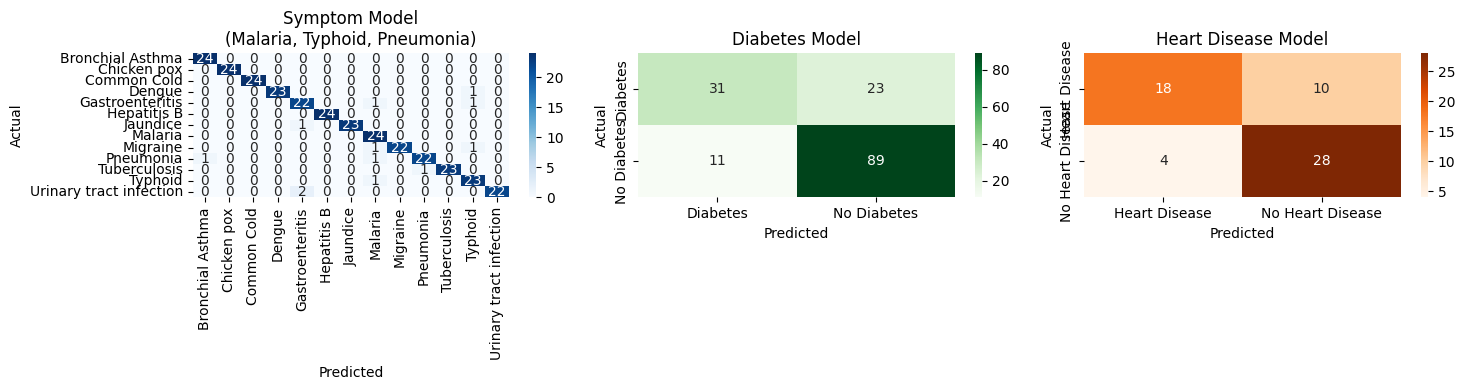

Saved as confusion_matrices.png


In [ ]:
# Confusion matrices for report
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Symptom model
cm1 = confusion_matrix(y_test_s, y_pred_s)
sns.heatmap(cm1, annot=True, fmt='d', ax=axes[0],
            xticklabels=model_symptoms.classes_,
            yticklabels=model_symptoms.classes_,
            cmap='Blues')
axes[0].set_title('Symptom Model\n(Common Diseases)')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Diabetes model
cm2 = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[1],
            xticklabels=model_diabetes.classes_,
            yticklabels=model_diabetes.classes_,
            cmap='Greens')
axes[1].set_title('Diabetes Model')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Heart model
cm3 = confusion_matrix(y_test_h, y_pred_h)
sns.heatmap(cm3, annot=True, fmt='d', ax=axes[2],
            xticklabels=model_heart.classes_,
            yticklabels=model_heart.classes_,
            cmap='Oranges')
axes[2].set_title('Heart Disease Model')
axes[2].set_ylabel('Actual')
axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as confusion_matrices.png")

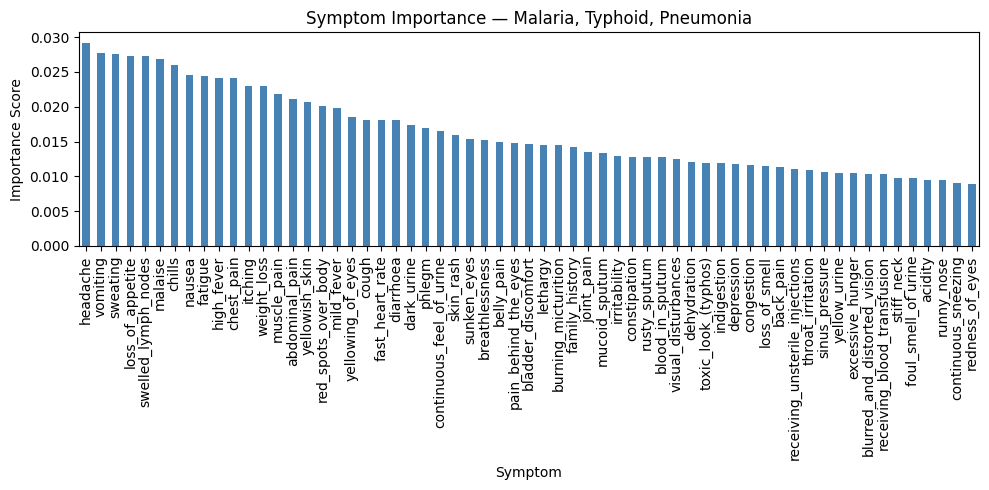

Saved as feature_importance.png


In [ ]:
# Feature importance for symptom model
feat_importance = pd.Series(
    model_symptoms.feature_importances_,
    index=X_symptoms.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_importance.plot(kind='bar', color='steelblue')
plt.title('Symptom Importance — Common Diseases')
plt.ylabel('Importance Score')
plt.xlabel('Symptom')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as feature_importance.png")

In [59]:
# Create models folder if it doesn't exist
os.makedirs('models', exist_ok=True)

# Export all three models
joblib.dump(model_symptoms, 'models/model_symptoms.pkl')
joblib.dump(model_diabetes, 'models/model_diabetes.pkl')
joblib.dump(model_heart, 'models/model_heart.pkl')

# Save symptom column names — needed by FastAPI later
symptom_columns = list(X_symptoms.columns)
with open('models/symptom_columns.json', 'w') as f:
    json.dump(symptom_columns, f)

# Save diabetes column names
diabetes_columns = list(X_diabetes.columns)
with open('models/diabetes_columns.json', 'w') as f:
    json.dump(diabetes_columns, f)

# Save heart column names
heart_columns = list(X_heart.columns)
with open('models/heart_columns.json', 'w') as f:
    json.dump(heart_columns, f)

print("All models exported successfully:")
print(os.listdir('models/'))

All models exported successfully:
['diabetes_columns.json', 'heart_columns.json', 'model_diabetes.pkl', 'model_heart.pkl', 'model_symptoms.pkl', 'symptom_columns.json']
